# Thesis — Emergent Behaviour Specialisation

Agent-based model of ant-like foraging with ACO-style movement. Each agent has personal **α** (exploitation) and **β** (exploration), with α + β = 1, and chooses its direction probabilistically from pheromone (τ) and resource heuristic (η).

Role comes from α: **exploiter** (α > 0.6), **explorer** (α < 0.4), **switcher** (otherwise). α/β adapt at runtime. Successful harvests raise α, long failure streaks raise β, crowding only steers movement spatially.

This notebook generates the results and figures underlying the thesis paper.

## 1 - Setup

Imports and global configuration (plotting style, pandas display, output folders).

In [1]:
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats as scipy_stats
from IPython.display import display

sys.path.insert(0, str(Path('.').resolve()))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')  

from src.simulation import Simulation
from src.experiments import run_experiment, run_sweep
from src.analysis import (
    compute_collective_metrics,
    compute_agent_metrics,
    compute_role_conditioned_metrics,
    compute_exploitation_index,
    cluster_behavioral_roles,
    per_run_corr_test,
    compare_environments_stats,
    check_test_assumptions,
    format_apa,
    oat_sensitivity_summary,
    plot_oat_sensitivity,
    plot_popmean_vs_exploiter_fraction,
    plot_role_fractions_over_time_ci,
    plot_role_occupancy_heatmap,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
Path('results/figures').mkdir(parents=True, exist_ok=True)
print("Imports OK")

C:\Users\timo_\AppData\Local\Temp\ipykernel_24156\18381741.py:9: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy import stats as scipy_stats


Imports OK


## 2 - Single Simulation Run

Run one configuration end-to-end to demonstrate the model and produce the per-agent, swarm and environment logs. Edit the parameters below to explore other settings.

In [3]:
# ── Edit these parameters to explore different configurations ──────────────
NUM_AGENTS              = 100
SIMULATION_STEPS        = 1500   
PATCH_DISTRIBUTION      = 'donut'   # 'gaussian' | 'uniform' | 'power_law' | 'donut' | 'ring' | 'gradient_in' | 'gradient_out' 
PHEROMONES_ENABLED      = True
PHEROMONE_WEIGHT        = 1.0          # trail-following strength (0 = ignore trails, 1 = full)
CROWDING_SENSITIVITY    = 1.0          # spatial dispersal strength only (does NOT affect alpha)
ENERGY_RETURN_THRESHOLD = 40.0         # energy below this starts homeward urgency (range 20-60)
DEPLETION_RATE          = 0.07         # cooldown = int(1/rate); 0.07 -> ~14 steps
N_ITEMS                 = 150          # resource items filling the environment
SEED                    = 42
ENABLE_VIEWER           = True        # True -> opens live Pygame window

print(f"Patch distribution : {PATCH_DISTRIBUTION} | {N_ITEMS} items")
print(f"Depletion rate     : {DEPLETION_RATE}  (cooldown = {int(1/DEPLETION_RATE)} steps)")
print(f"Agents             : {NUM_AGENTS} identical (alpha=beta=0.5), spawned at the nest")
print(f"Crowding sens.     : {CROWDING_SENSITIVITY} (spatial only) | Pheromone weight: {PHEROMONE_WEIGHT}")
print(f"Energy return thr. : {ENERGY_RETURN_THRESHOLD}  (urgency fires below this level)")
print(f"Steps              : {SIMULATION_STEPS} | Pheromones: {PHEROMONES_ENABLED}")

Patch distribution : donut | 150 items
Depletion rate     : 0.07  (cooldown = 14 steps)
Agents             : 100 identical (alpha=beta=0.5), spawned at the nest
Crowding sens.     : 1.0 (spatial only) | Pheromone weight: 1.0
Energy return thr. : 40.0  (urgency fires below this level)
Steps              : 1500 | Pheromones: True


In [15]:
sim = Simulation(
    num_agents=NUM_AGENTS,
    patch_distribution=PATCH_DISTRIBUTION,
    pheromones_enabled=PHEROMONES_ENABLED,
    seed=SEED,
    depletion_rate=DEPLETION_RATE,
    n_items=N_ITEMS,
    crowding_sensitivity=CROWDING_SENSITIVITY,
    pheromone_weight=PHEROMONE_WEIGHT,
    energy_return_threshold=ENERGY_RETURN_THRESHOLD,
)

if ENABLE_VIEWER:
    agent_df, env_df, swarm_df, switch_df = sim.run_live(SIMULATION_STEPS)
else:
    agent_df, env_df, swarm_df, switch_df = sim.run(SIMULATION_STEPS)

print(f"agent_df  : {agent_df.shape}")
print(f"swarm_df  : {swarm_df.shape}")
print(f"env_df    : {env_df.shape}")
print(f"switch_df : {switch_df.shape}")
agent_df[['step', 'agent_id', 'alpha', 'beta', 'role', 'energy', 'speed']].head(8)

agent_df  : (108500, 23)
swarm_df  : (1085, 19)
env_df    : (1085, 9)
switch_df : (1171, 7)


,step,agent_id,alpha,beta,role,energy,speed
0,0,0,0.5167,0.4833,switcher,100.0000,1.0600
1,0,1,0.5058,0.4942,switcher,99.8935,1.0600
2,0,2,0.5058,0.4942,switcher,99.8935,1.0600
3,0,3,0.5058,0.4942,switcher,99.8935,1.0600
4,0,4,0.5058,0.4942,switcher,99.8935,1.0600
5,0,5,0.5058,0.4942,switcher,99.8935,1.0600
6,0,6,0.5058,0.4942,switcher,99.8935,1.0600
7,0,7,0.5058,0.4942,switcher,99.8935,1.0600


## 3 - Save Logs

Write the four log tables (agents, environment, swarm, switches) to `data/logs/` as CSV.

In [4]:
# Saves four CSVs to data/logs/{agents | environment | swarm | switches}/
sim.save_logs()


Logs saved to C:\Users\timo_\OneDrive\Bureau\unif\VU_Amsterdam\Thesis\data\logs/


WindowsPath('C:/Users/timo_/OneDrive/Bureau/unif/VU_Amsterdam/Thesis/data/logs')

## 4 - Simulation Summary

Headline numbers for the single run: total collected, efficiency, coverage, diversity, the final role mix, and how mean α shifted from start to end.

In [5]:
assert agent_df['role'].nunique() >= 2, "Expected at least 2 distinct roles"

metrics = compute_collective_metrics(agent_df, swarm_df)

print("=" * 52)
print("SIMULATION SUMMARY")
print("=" * 52)
print(f"  Total resources collected : {metrics['total_collected']:.2f}")
print(f"  Efficiency (coll./dist.)  : {metrics['efficiency']:.5f}")
print(f"  Coverage fraction         : {metrics['final_coverage']:.3f}")
print(f"  Mean Shannon H (diversity): {metrics['mean_shannon_diversity']:.3f}")
print()

print("Final role distribution:")
final_roles = agent_df.groupby('agent_id')['role'].last().value_counts(normalize=True)
for role, frac in final_roles.items():
    bar = "█" * int(frac * 30)
    print(f"  {role:<12}: {frac*100:5.1f}%  {bar}")
print()

crisis_steps = int(swarm_df['crisis_active'].sum())
print(f"Crisis events : {crisis_steps} steps ({crisis_steps/SIMULATION_STEPS*100:.1f}% of run)")

step_max    = agent_df['step'].max()
alpha_start = agent_df[agent_df['step'] == 0]['alpha'].mean()
alpha_end   = agent_df[agent_df['step'] == step_max]['alpha'].mean()
print(f"Mean α        : {alpha_start:.3f} (start) → {alpha_end:.3f} (end)   Δ={alpha_end-alpha_start:+.3f}")

SIMULATION SUMMARY
  Total resources collected : 3135.00
  Efficiency (coll./dist.)  : 0.01673
  Coverage fraction         : 0.783
  Mean Shannon H (diversity): 0.593

Final role distribution:
  explorer    :  87.0%  ██████████████████████████
  exploiter   :  10.0%  ███
  switcher    :   3.0%  

Crisis events : 0 steps (0.0% of run)
Mean α        : 0.506 (start) → 0.227 (end)   Δ=-0.279


## 5 - Methodology: Resource Distributions

The independent variable: seven spatial layouts of the resource field, built exactly as the simulation builds them. The figure (saved to `results/figures/`) shows where items sit relative to the central nest (red star).

In [22]:
# 5 - Plot the seven resource distributions exactly as the simulation builds them; saves to results/figures/.
import math
from src.environment import ResourcePatch

FIG_DIR = Path('results/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

ENV_DISTRIBUTIONS = ['gaussian', 'uniform', 'power_law',
                     'ring', 'donut', 'gradient_in', 'gradient_out']


def plot_environment_distributions(distributions=ENV_DISTRIBUTIONS,
                                   width=100.0, height=100.0,
                                   n_items=150, seed=42,
                                   save_as=FIG_DIR / 'environment_distributions.png'):
    """Scatter the resource items of each distribution; red star = central nest."""
    radius = math.hypot(width, height) / 2.0
    n = len(distributions)
    ncol = 4
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 3.0 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, dist in zip(axes, distributions):
        rng = np.random.default_rng(seed)          # same seed -> comparable layouts
        patch = ResourcePatch(0, width / 2, height / 2, radius=radius,
                              n_items=n_items, distribution=dist,
                              rng=rng, bounds=(width, height))
        xs = [it.x for it in patch.items]
        ys = [it.y for it in patch.items]
        ax.scatter(xs, ys, s=6, alpha=0.6, color='#2c7fb8')
        ax.scatter([width / 2], [height / 2], marker='*', s=160,
                   color='crimson', zorder=5)
        ax.set_title(dist, fontsize=10)
        ax.set_xlim(0, width); ax.set_ylim(0, height)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('Resource distributions (red star = nest at centre)', fontsize=12)
    fig.tight_layout()
    fig.savefig(save_as, dpi=150, bbox_inches='tight')
    print('saved', save_as)
    return fig


plot_environment_distributions();



saved results\figures\environment_distributions.png


## 6 - Environment Comparison

Run the **same agents** across all seven environments, `N_SEEDS` seeds each. Question: how does the resource layout reshape the emergent role mix (exploiters / explorers / switchers)?

In [4]:
# 6a - Run all seven environments with identical agents over N_SEEDS seeds (or load saved results).
# Each ENVIRONMENTS entry overrides only the resource layout, everything else stays fixed.
ENVIRONMENTS = {
    'gaussian':     dict(patch_distribution='gaussian'),
    'uniform':      dict(patch_distribution='uniform'),
    'power_law':    dict(patch_distribution='power_law'),
    'ring':         dict(patch_distribution='ring'),
    'donut':        dict(patch_distribution='donut'),
    'gradient_out': dict(patch_distribution='gradient_out'),
    'gradient_in':  dict(patch_distribution='gradient_in'),
}
N_SEEDS = 30  

# LOAD_FROM_CSV=True rebuilds tables from results/data/ CSVs; False re-runs sims.
DATA_DIR = Path('results/data'); DATA_DIR.mkdir(parents=True, exist_ok=True)
LOAD_FROM_CSV = True 

BASE_CFG = dict(
    num_agents=NUM_AGENTS, steps=SIMULATION_STEPS,
    pheromones_enabled=PHEROMONES_ENABLED, depletion_rate=DEPLETION_RATE,
    n_items=N_ITEMS, crowding_sensitivity=CROWDING_SENSITIVITY,
    pheromone_weight=PHEROMONE_WEIGHT, energy_return_threshold=ENERGY_RETURN_THRESHOLD,
)

if LOAD_FROM_CSV:
    env_metrics = pd.read_csv(DATA_DIR / 'env_metrics.csv')
    env_summary = pd.read_csv(DATA_DIR / 'env_summary.csv')
    role_long  = pd.read_csv(DATA_DIR / 'env_role_metrics.csv')
    swarm_long = pd.read_csv(DATA_DIR / 'env_swarm.csv')
    pos_long   = pd.read_csv(DATA_DIR / 'env_pos.csv')
    env_metrics_by      = {n: g.reset_index(drop=True) for n, g in env_metrics.groupby('environment')}
    env_role_metrics_by = {n: g.reset_index(drop=True) for n, g in role_long.groupby('environment')}
    env_swarm_by = {n: [s.drop(columns=['environment', 'seed']).reset_index(drop=True)
                        for _, s in g.groupby('seed')]
                    for n, g in swarm_long.groupby('environment')}
    env_pos_by   = {n: g.drop(columns=['environment']).reset_index(drop=True)
                    for n, g in pos_long.groupby('environment')}
    print(f'Loaded {len(env_summary)} runs from {DATA_DIR} (no simulation).')
else:
    env_metrics_by, env_role_metrics_by = {}, {}
    env_swarm_by, env_pos_by = {}, {}
    env_rows, _all = [], []
    total = len(ENVIRONMENTS) * N_SEEDS
    k = 0
    for name, overrides in ENVIRONMENTS.items():
        per, roleper, swarms, posns = [], [], [], []
        for si in range(N_SEEDS):
            seed = SEED + si
            k += 1
            print(f'[{k}/{total}] {name} | seed {seed}')
            row, adf, _, sdf, _ = run_experiment(**{**BASE_CFG, **overrides, 'seed': seed})
            am = compute_agent_metrics(adf)
            am['environment'] = name; am['seed'] = seed
            per.append(am)
            rc = compute_role_conditioned_metrics(adf)
            rc['environment'] = name; rc['seed'] = seed
            roleper.append(rc)
            row['environment'] = name; row['seed'] = seed
            row['pop_dist_nest_mean'] = float(am['dist_nest_mean'].mean())
            row['pop_gyration_mean']  = float(am['gyration_radius'].mean())
            env_rows.append(row)
            swarms.append(sdf)
            s0, s1 = adf['step'].min(), adf['step'].max()
            cutoff = s0 + 0.5 * (s1 - s0)
            posns.append(adf.loc[adf['step'] >= cutoff, ['x', 'y', 'role', 'step']])
        env_metrics_by[name]      = pd.concat(per, ignore_index=True)
        env_role_metrics_by[name] = pd.concat(roleper, ignore_index=True)
        env_swarm_by[name]        = swarms
        env_pos_by[name]          = pd.concat(posns, ignore_index=True)
        _all.append(env_metrics_by[name])
    env_metrics = pd.concat(_all, ignore_index=True)
    env_summary = pd.DataFrame(env_rows)
    # persist analysis-ready tables as plain CSV
    env_metrics.to_csv(DATA_DIR / 'env_metrics.csv', index=False)
    env_summary.to_csv(DATA_DIR / 'env_summary.csv', index=False)
    pd.concat(env_role_metrics_by.values(), ignore_index=True).to_csv(
        DATA_DIR / 'env_role_metrics.csv', index=False)
    pd.concat([s.assign(environment=n, seed=SEED + j)
               for n, L in env_swarm_by.items() for j, s in enumerate(L)],
              ignore_index=True).to_csv(DATA_DIR / 'env_swarm.csv', index=False)
    pd.concat([g.assign(environment=n) for n, g in env_pos_by.items()],
              ignore_index=True).to_csv(DATA_DIR / 'env_pos.csv', index=False)
    print(f'\nDone: {len(env_summary)} runs, {len(env_metrics)} agent-rows. '
          f'Saved CSVs to {DATA_DIR}.')

Loaded 210 runs from results\data (no simulation).


In [8]:
# 6b - Cluster agents into behavioural roles and build the Foraging-Exploitation Index (FEI).
env_metrics = cluster_behavioral_roles(env_metrics, k=3, method='gmm', random_state=0)
env_metrics, fei_info = compute_exploitation_index(env_metrics)   # adds 'exploitation_index'
env_metrics_by = {name: g for name, g in env_metrics.groupby('environment')}

# population-mean FEI per run (one value per environment x seed) -> env_summary
pop_fei = (env_metrics.groupby(['environment', 'seed'])['exploitation_index']
           .mean().rename('pop_exploitation_index').reset_index())
env_summary = env_summary.merge(pop_fei, on=['environment', 'seed'], how='left')

print('behavioural_role attached. cluster sizes:',
      env_metrics['behavioral_role'].value_counts().to_dict())
print('FEI: PC1 explains %.1f%% of variance | loadings: %s'
      % (100 * fei_info['explained_variance_ratio'],
         {kk: round(vv, 2) for kk, vv in fei_info['loadings'].items()}))


behavioural_role attached. cluster sizes: {'switcher': 9064, 'exploiter': 8626, 'explorer': 3310}
FEI: PC1 explains 62.9% of variance | loadings: {'gyration_radius': 0.26, 'local_resource_mean': 0.7, 'yield_per_distance': 0.67}


In [9]:
# 6c - Emergent role mix per environment, plus how role (alpha) correlates with distance-to-nest.
roles3 = ['exploiter', 'explorer', 'switcher']
mix_cols = [f'timeavg_window_{r}_frac' for r in roles3]
mix_cols = [c for c in mix_cols if c in env_summary]
print('Time-averaged role mix per environment (settled window, population share):')
display(env_summary.groupby('environment')[mix_cols]
        .mean().reindex(list(ENVIRONMENTS)).round(3))

# Does the warm-up change the story? settled window vs whole run.
span_cols = [f'timeavg_{s}_{r}_frac' for s in ['window', 'whole'] for r in roles3]
span_cols = [c for c in span_cols if c in env_summary]
print('\nSettled window vs whole run (warm-up included):')
display(env_summary.groupby('environment')[span_cols]
        .mean().reindex(list(ENVIRONMENTS)).round(3))

# Spatial anchoring: per-run mean r +/- 95% CI on window-mean alpha.
anchor = per_run_corr_test(env_metrics, 'dist_nest_mean', 'alpha_mean_window').set_index('environment')
print('\nAnchoring corr(dist_to_nest, window-mean alpha): mean r +/- 95% CI (n runs):')
for name in ENVIRONMENTS:
    if name in anchor.index:
        r = anchor.loc[name]
        print(f"  {name:<13}: r = {r['mean_r']:+.3f}  "
              f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]  (n={int(r['n_runs'])})")


Time-averaged role mix per environment (settled window, population share):


,timeavg_window_exploiter_frac,timeavg_window_explorer_frac,timeavg_window_switcher_frac
environment,,,
gaussian,0.5740,0.2390,0.1870
uniform,0.1160,0.7930,0.0920
power_law,0.4860,0.3240,0.1900
ring,0.0870,0.8820,0.0310
donut,0.3840,0.4650,0.1510
gradient_out,0.1090,0.7800,0.1110
gradient_in,0.3960,0.4300,0.1750



Settled window vs whole run (warm-up included):


,timeavg_window_exploiter_frac,timeavg_window_explorer_frac,timeavg_window_switcher_frac,timeavg_whole_exploiter_frac,timeavg_whole_explorer_frac,timeavg_whole_switcher_frac
environment,,,,,,
gaussian,0.5740,0.2390,0.1870,0.5440,0.2600,0.1960
uniform,0.1160,0.7930,0.0920,0.1080,0.7790,0.1130
power_law,0.4860,0.3240,0.1900,0.4550,0.3460,0.1980
ring,0.0870,0.8820,0.0310,0.1430,0.7920,0.0650
donut,0.3840,0.4650,0.1510,0.3490,0.4800,0.1700
gradient_out,0.1090,0.7800,0.1110,0.1030,0.7750,0.1230
gradient_in,0.3960,0.4300,0.1750,0.3800,0.4410,0.1790



Anchoring corr(dist_to_nest, window-mean alpha): mean r +/- 95% CI (n runs):
  gaussian     : r = -0.717  [-0.739, -0.695]  (n=30)
  uniform      : r = +0.856  [+0.842, +0.870]  (n=30)
  power_law    : r = -0.647  [-0.673, -0.620]  (n=30)
  ring         : r = +0.924  [+0.919, +0.928]  (n=30)
  donut        : r = +0.725  [+0.697, +0.751]  (n=30)
  gradient_out : r = +0.623  [+0.562, +0.681]  (n=30)
  gradient_in  : r = -0.592  [-0.614, -0.571]  (n=30)


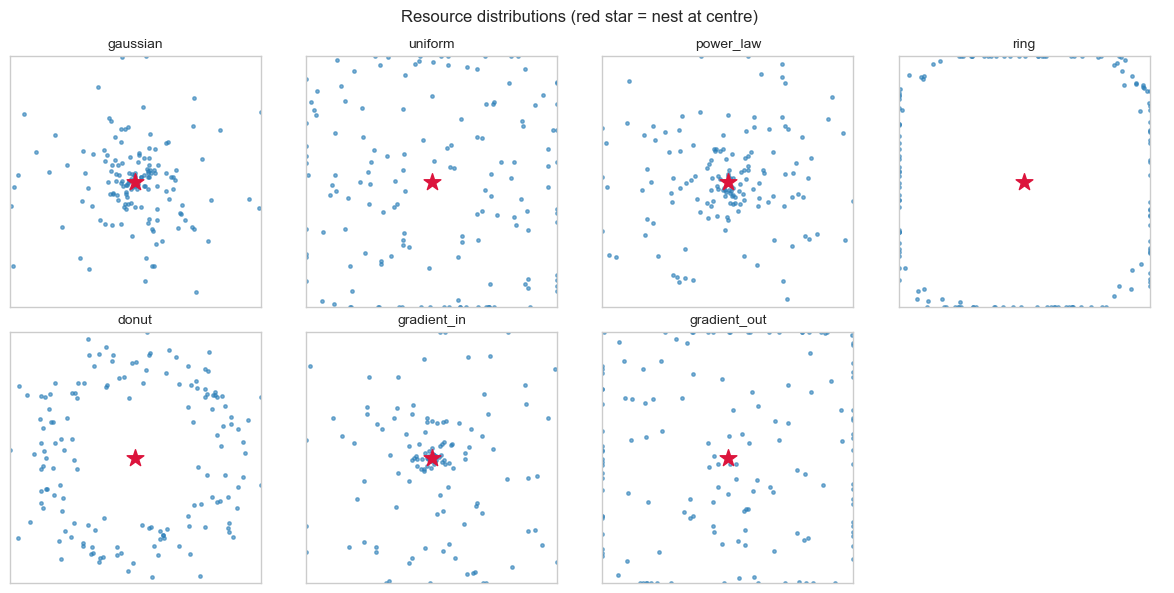

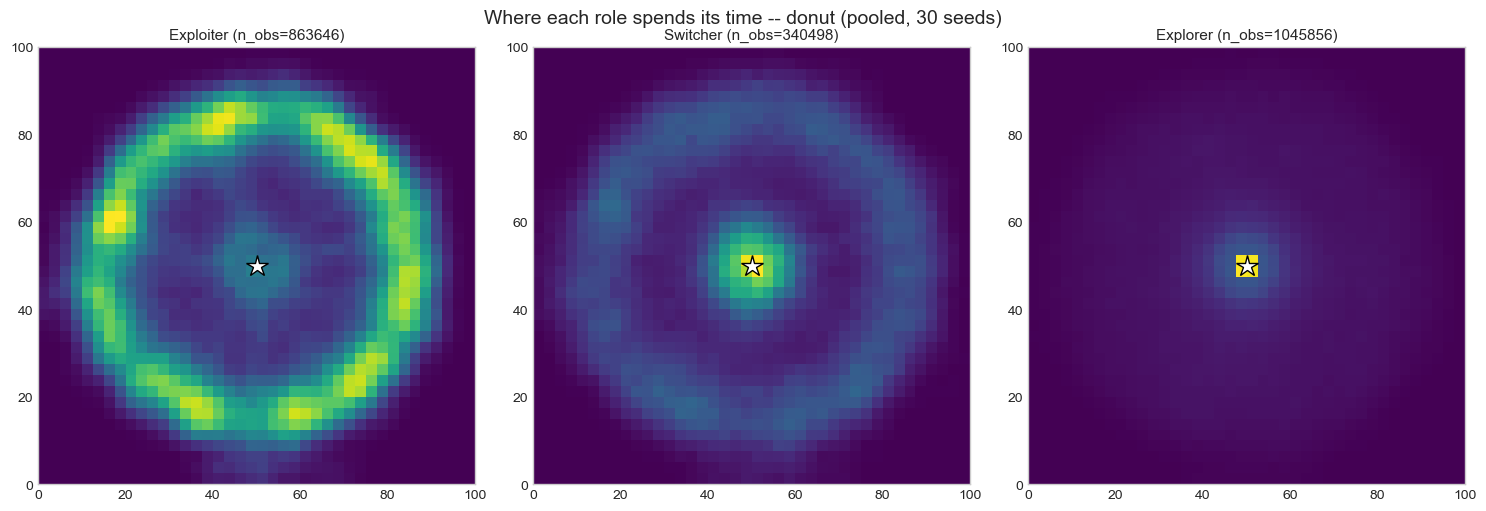

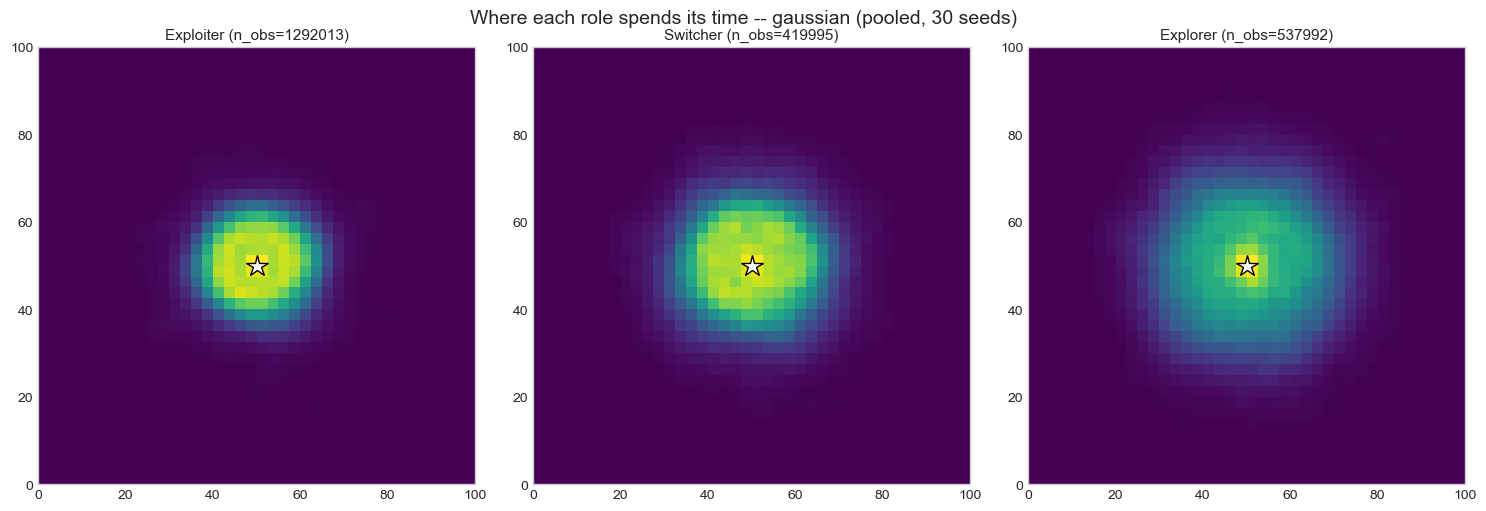

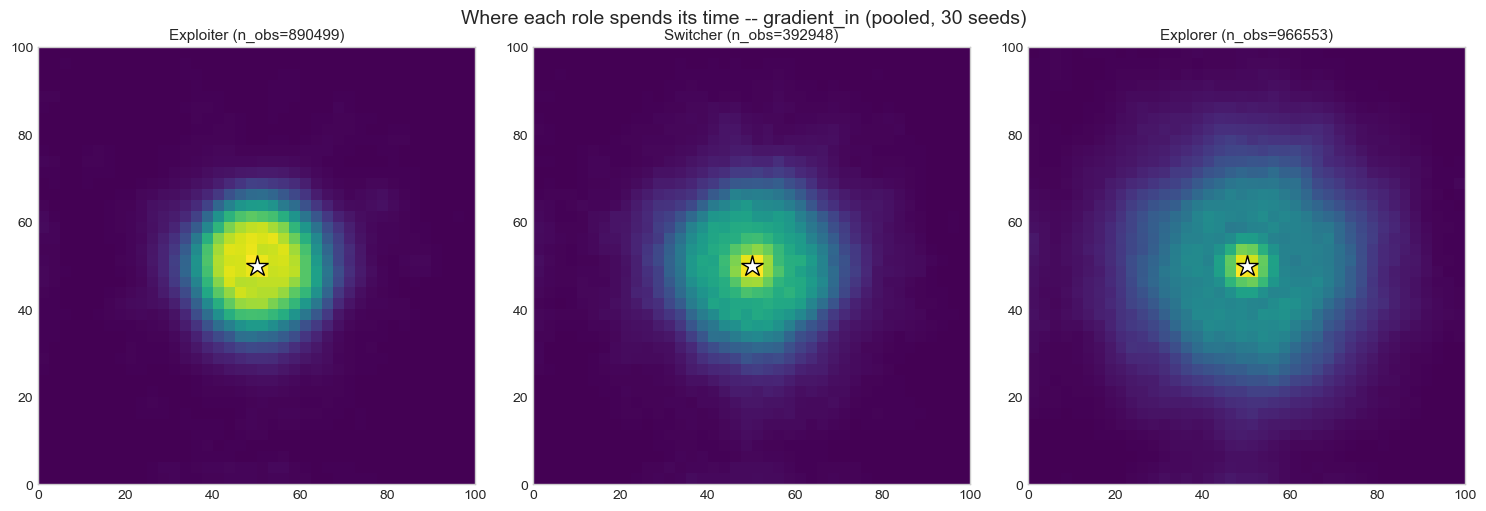

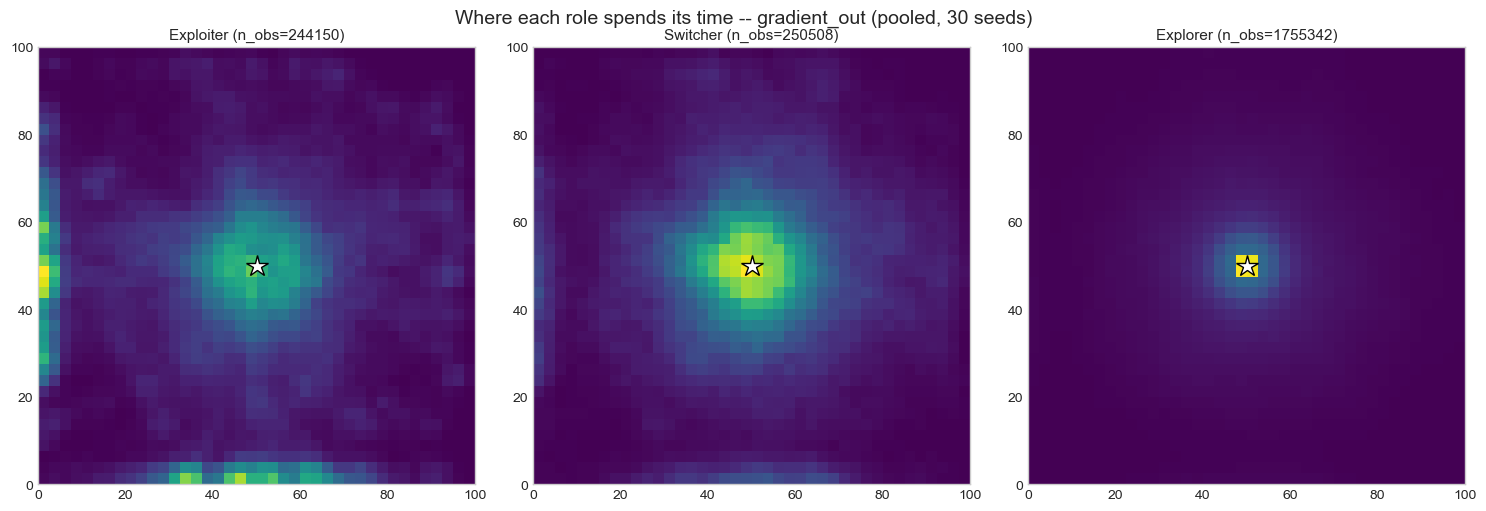

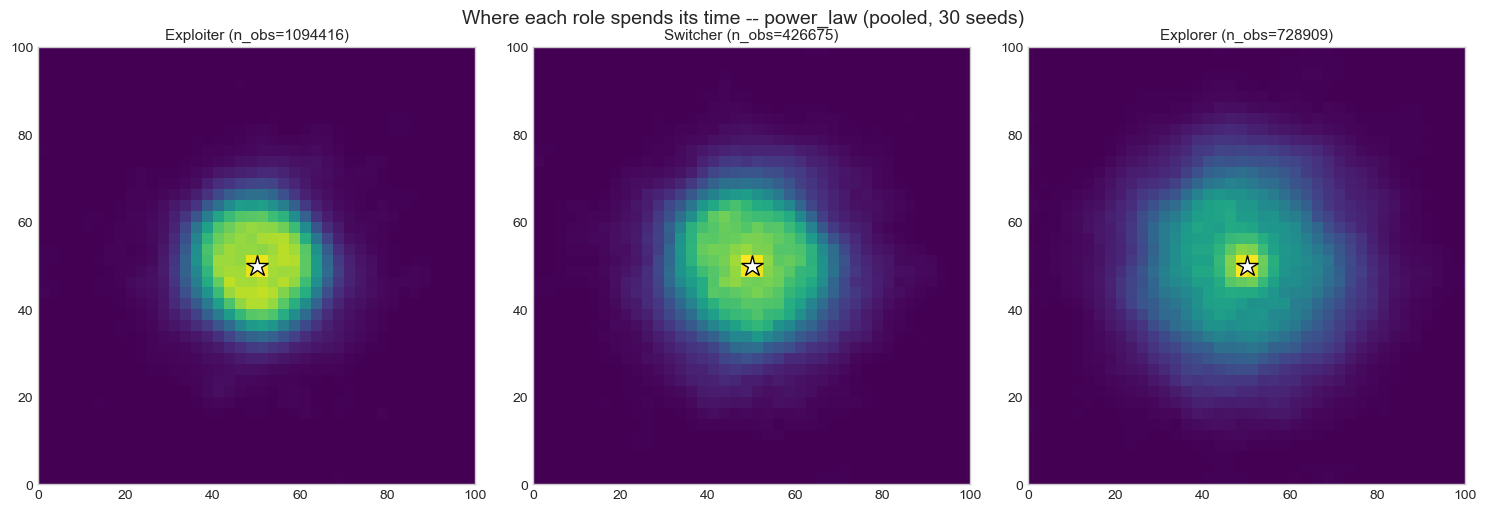

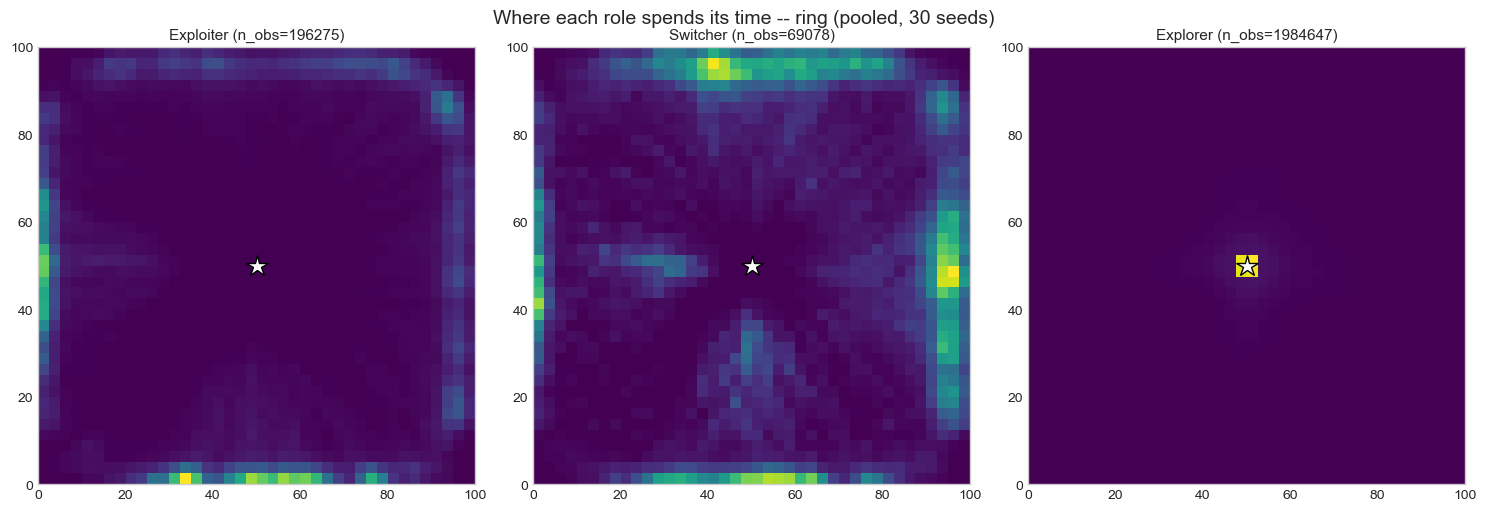

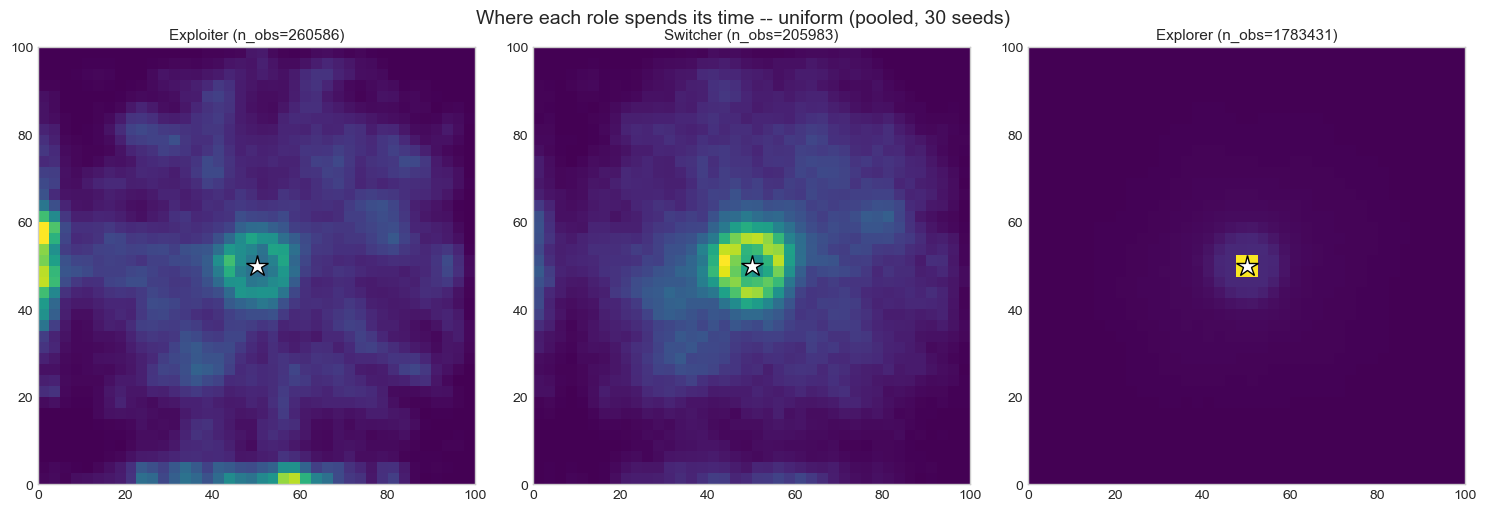

In [10]:
# 6d - Occupancy heatmaps: where each role spends its time, per environment (pooled over seeds).
for name, pos in env_pos_by.items():
    fig = plot_role_occupancy_heatmap(pos, window_frac=0.0)  # already windowed
    fig.suptitle(f"Where each role spends its time -- {name} (pooled, {N_SEEDS} seeds)",
                 fontsize=14)
    fig.savefig(f'results/figures/compare_occupancy_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


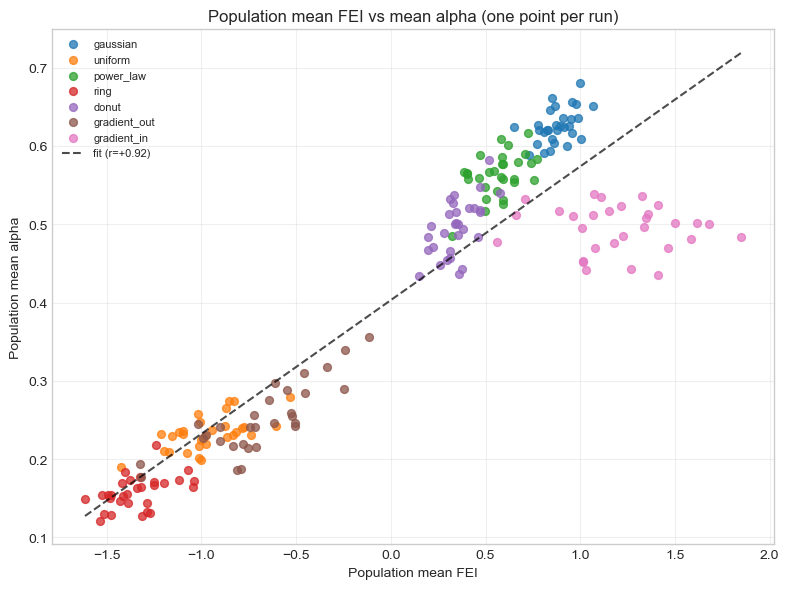

In [11]:
# 6e - Population-mean FEI vs population-mean alpha, one point per run (FEI should track alpha).
fig = plot_popmean_vs_exploiter_fraction(
    env_summary, x='pop_exploitation_index', y='mean_alpha_final')
fig.axes[0].set_ylabel('Population mean alpha')
fig.axes[0].set_title('Population mean FEI vs mean alpha (one point per run)')
fig.savefig('results/figures/popfei_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 - Population Dynamics Over Time

Role fractions and resource collection over the course of a run, averaged across seeds with a confidence band — shows how roles emerge and settle rather than just the final mix.

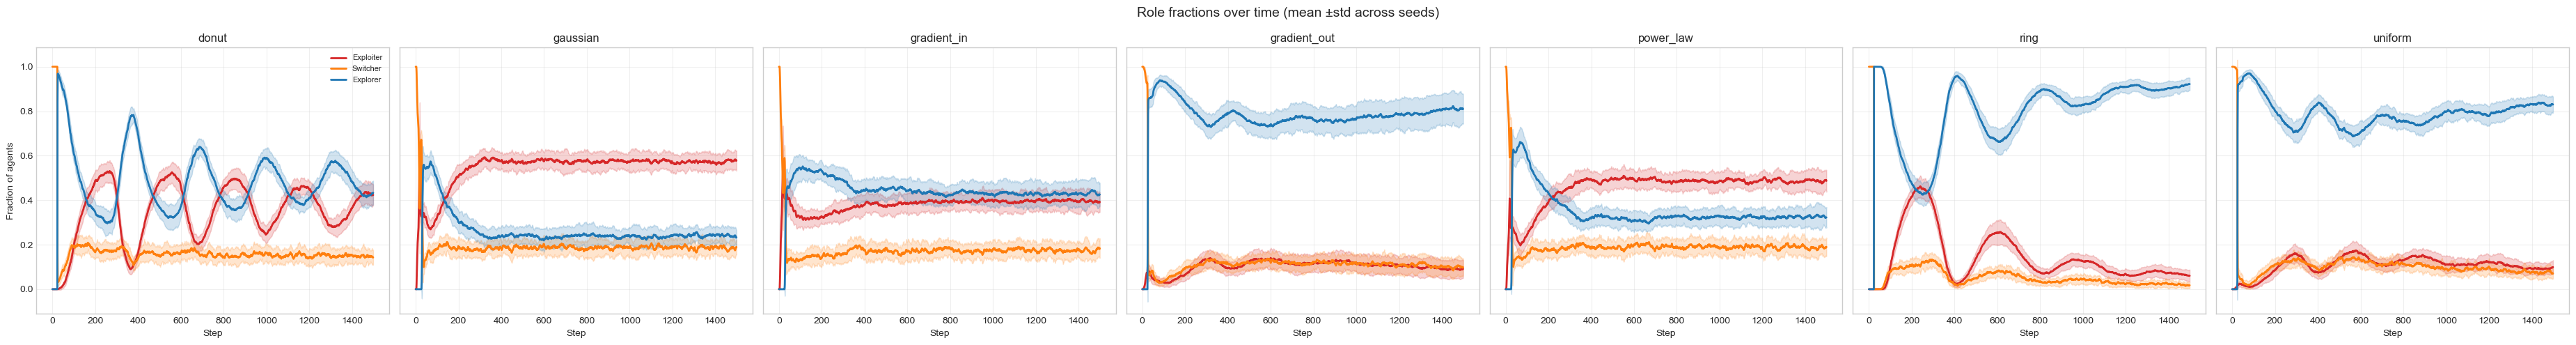

In [12]:
# 7a - Role fractions over time, mean +/- band across seeds.
fig = plot_role_fractions_over_time_ci(env_swarm_by)
fig.savefig('results/figures/role_fractions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 - Foraging-Exploitation Signature and Role Distribution

**RQ:** does the local environment shape emergent specialisation through the agents' foraging-exploitation signature?

The **Foraging-Exploitation Index (FEI)** is the first principal component of three standardized, distribution-invariant behaviours: low mobility, high local resource (rich neighbourhood) and high yield per distance (efficient delivery). It is oriented so high FEI = exploiter-like. **8a** shows the three behaviours move together and track α; **8b** builds the FEI and relates it to the exploiter share. Distance to nest is kept separate because its sign flips by environment.

#### 8a - Per-map correlation of each behaviour with $\alpha$

Mobility (gyration), resource exposure and efficiency versus α in each environment; signs flip between centre-heavy and periphery-heavy maps.

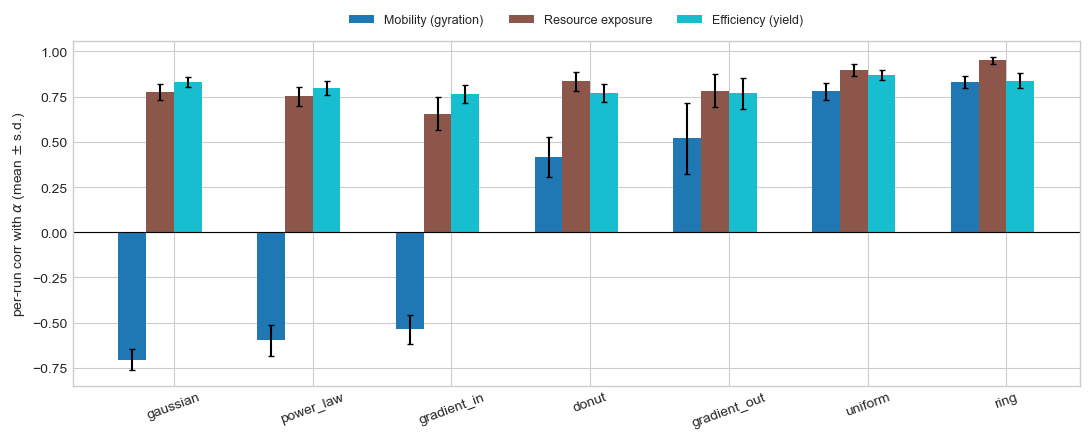

In [13]:
# 8a - Per-run correlation of each behaviour with alpha, by map (mean +/- s.d. over seeds),
# maps ordered centre -> periphery.
try:
    _df = env_metrics
except NameError:
    _df = pd.read_csv('results/data/env_metrics.csv')

ALPHA_COL = 'alpha_mean_window'
CORR_METRICS = ['gyration_radius', 'local_resource_mean', 'yield_per_distance']
METRIC_LABELS = {'gyration_radius': 'Mobility (gyration)', 'local_resource_mean': 'Resource exposure',
                 'yield_per_distance': 'Efficiency (yield)', }
ENV_ORDER = ['gaussian', 'power_law', 'gradient_in', 'donut', 'gradient_out', 'uniform', 'ring']


def _per_run_metric_corr(df, metric, env):
    rs = []
    for _, g in df[df.environment == env].groupby('seed'):
        a = g[ALPHA_COL].values; b = g[metric].values
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() > 2 and a[m].std() > 0 and b[m].std() > 0:
            rs.append(np.corrcoef(a[m], b[m])[0, 1])
    return np.array(rs)


_envs = [e for e in ENV_ORDER if e in _df['environment'].unique()]
_means = {m: [] for m in CORR_METRICS}; _stds = {m: [] for m in CORR_METRICS}
for e in _envs:
    for met in CORR_METRICS:
        rs = _per_run_metric_corr(_df, met, e)
        _means[met].append(np.nanmean(rs) if len(rs) else np.nan)
        _stds[met].append(rs.std(ddof=1) if len(rs) > 1 else 0.0)

_x = np.arange(len(_envs)); _w = 0.2
fig, ax = plt.subplots(figsize=(11, 4.5))
_cols = plt.cm.tab10(np.linspace(0, 1, len(CORR_METRICS)))
for i, met in enumerate(CORR_METRICS):
    ax.bar(_x + (i - 1.5) * _w, _means[met], _w, yerr=_stds[met], capsize=2,
           label=METRIC_LABELS[met], color=_cols[i])
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(_x); ax.set_xticklabels(_envs, rotation=20)
ax.set_ylabel(r'per-run corr with $\alpha$ (mean $\pm$ s.d.)')
ax.legend(ncol=4, fontsize=9, loc='lower center', bbox_to_anchor=(0.5, 1.01))
fig.tight_layout()
fig.savefig('results/figures/metric_alpha_corr_by_map.png', dpi=150, bbox_inches='tight')
plt.show()


Foraging-Exploitation Index (FEI):
  PC1 explains 62.9% of the variance in the three features.
  loadings: {'gyration_radius': 0.26, 'local_resource_mean': 0.696, 'yield_per_distance': 0.669}


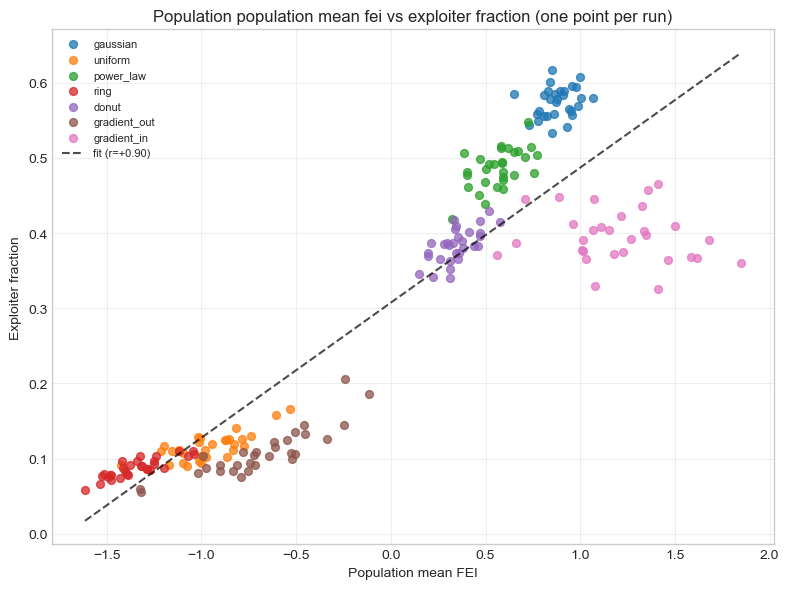

In [14]:
# 8b - Report the FEI loadings, then plot population-mean FEI vs exploiter fraction across runs.
print('Foraging-Exploitation Index (FEI):')
print('  PC1 explains %.1f%% of the variance in the three features.'
      % (100 * fei_info['explained_variance_ratio']))
print('  loadings:', {kk: round(vv, 3) for kk, vv in fei_info['loadings'].items()})

# macro level -- population-mean FEI vs exploiter fraction (one pt / run).
fig = plot_popmean_vs_exploiter_fraction(
    env_summary, x='pop_exploitation_index', y='timeavg_window_exploiter_frac')
fig.savefig('results/figures/popfei_vs_exploiterfrac.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 - Statistical Tests

Significance with the **run (seed) as the unit of analysis** (n = `N_SEEDS` per environment) to avoid pseudo-replicating non-independent agents. Exploratory, α = .05.

**9a — Is the behaviour to role link real? ** For each run, one Pearson r between a behaviour and window-mean α, then a one sample t-test of the r against 0. Expect distance-to-nest to flip sign across environments while the FEI stays positive everywhere.

In [15]:
# 9a - Per-run correlations (distance-to-nest and FEI vs alpha), t-tested against 0.
print('Anchoring: corr(distance-to-nest, alpha) per run:')
display(per_run_corr_test(env_metrics, 'dist_nest_mean', 'alpha_mean_window').round(4))
print('\nFEI: corr(Foraging-Exploitation Index, alpha) per run:')
display(per_run_corr_test(env_metrics, 'exploitation_index', 'alpha_mean_window').round(4))


Anchoring: corr(distance-to-nest, alpha) per run:


,environment,mean_r,std_r,ci_low,ci_high,t_vs_0,p_value,n_runs
0,donut,0.7246,0.0773,0.6965,0.7509,51.3135,0.0000,30
1,gaussian,-0.7173,0.0633,-0.7394,-0.6949,-62.0945,0.0000,30
2,gradient_in,-0.5925,0.0623,-0.6143,-0.5709,-52.0689,0.0000,30
3,gradient_out,0.6226,0.1680,0.5619,0.6810,20.3010,0.0000,30
4,power_law,-0.6475,0.0752,-0.6729,-0.6195,-47.1769,0.0000,30
5,ring,0.9237,0.0130,0.9190,0.9281,389.0722,0.0000,30
6,uniform,0.8563,0.0409,0.8420,0.8704,114.5841,0.0000,30



FEI: corr(Foraging-Exploitation Index, alpha) per run:


,environment,mean_r,std_r,ci_low,ci_high,t_vs_0,p_value,n_runs
0,donut,0.8653,0.0448,0.8484,0.8799,105.8158,0.0000,30
1,gaussian,0.8277,0.0283,0.8175,0.8375,159.9579,0.0000,30
2,gradient_in,0.7171,0.0768,0.6895,0.7437,51.1599,0.0000,30
3,gradient_out,0.8106,0.0784,0.7825,0.8379,56.6124,0.0000,30
4,power_law,0.8000,0.0350,0.7878,0.8123,125.0571,0.0000,30
5,ring,0.9475,0.0114,0.9435,0.9514,455.8171,0.0000,30
6,uniform,0.9102,0.0240,0.9018,0.9183,208.0520,0.0000,30


**9b — Do the environments actually differ?** One value per run, then ANOVA + Kruskal–Wallis omnibus tests, followed by pairwise Welch t-tests with Benjamini–Hochberg FDR. `reject_fdr = True` flags the pairs that genuinely differ.

In [16]:
# 9b - Omnibus + pairwise tests: do the environments differ on the run-level outcomes?
metrics_to_test = ['timeavg_window_exploiter_frac', 'timeavg_window_explorer_frac',
                   'mean_shannon_diversity', 'pop_dist_nest_mean',
                   'pop_exploitation_index']
metrics_to_test = tuple(m for m in metrics_to_test if m in env_summary)
compare_environments_stats(env_summary, metrics=metrics_to_test).round(4)


,metric,test,statistic,p_value,n,df1,df2,eta_sq,eps_sq,cohens_d,p_adj,p_holm,reject_fdr
0,timeavg_window_exploiter_frac,ANOVA (omnibus),1905.1344,0.0000,210,6.0000,203.0000,0.9826,NaN,NaN,NaN,NaN,NaN
1,timeavg_window_exploiter_frac,Kruskal-Wallis (omnibus),191.4714,0.0000,210,6.0000,NaN,NaN,0.9161,NaN,NaN,NaN,NaN
2,timeavg_window_exploiter_frac,Welch t: gaussian vs uniform,92.0018,0.0000,60,NaN,NaN,NaN,NaN,23.7548,0.0000,0.0000,True
3,timeavg_window_exploiter_frac,Welch t: gaussian vs power_law,14.4310,0.0000,60,NaN,NaN,NaN,NaN,3.7261,0.0000,0.0000,True
4,timeavg_window_exploiter_frac,Welch t: gaussian vs ring,111.0346,0.0000,60,NaN,NaN,NaN,NaN,28.6690,0.0000,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,pop_exploitation_index,Welch t: ring vs gradient_out,-11.1619,0.0000,60,NaN,NaN,NaN,NaN,-2.8820,0.0000,0.0000,True
111,pop_exploitation_index,Welch t: ring vs gradient_in,-41.7258,0.0000,60,NaN,NaN,NaN,NaN,-10.7736,0.0000,0.0000,True
112,pop_exploitation_index,Welch t: donut vs gradient_out,18.7456,0.0000,60,NaN,NaN,NaN,NaN,4.8401,0.0000,0.0000,True
113,pop_exploitation_index,Welch t: donut vs gradient_in,-14.8574,0.0000,60,NaN,NaN,NaN,NaN,-3.8362,0.0000,0.0000,True


**9c — Which omnibus test to trust?** Shapiro–Wilk (normality) and Levene (equal variance) per metric. `parametric_ok = True` ->  the ANOVA row =  `False` -> prefer Kruskal–Wallis.

In [17]:
# 9c - Normality + equal-variance checks to justify ANOVA vs Kruskal-Wallis per metric.
check_test_assumptions(env_summary, metrics=metrics_to_test).round(4)


,metric,shapiro_min_p,levene_stat,levene_p,normal_ok,homoscedastic_ok,parametric_ok
0,timeavg_window_exploiter_frac,0.0223,3.8995,0.0010,False,False,False
1,timeavg_window_explorer_frac,0.1902,7.1154,0.0000,True,False,False
2,mean_shannon_diversity,0.0146,22.2611,0.0000,False,False,False
3,pop_dist_nest_mean,0.2252,11.9045,0.0000,True,False,False
4,pop_exploitation_index,0.3267,9.5073,0.0000,True,False,False


**9d — Plain-language summary.** The same omnibus tests in APA format, plus the environment pairs that stay significant after FDR correction

In [18]:
# 9d - APA-style summary of the omnibus tests, plus the FDR-significant environment pairs.
stats_tbl = compare_environments_stats(env_summary, metrics=metrics_to_test)
print("Omnibus tests (run-level, n = N_SEEDS per environment):\n")
for _, row in stats_tbl[stats_tbl['test'].str.contains('omnibus')].iterrows():
    print(f"  {row['metric']:<28} {row['test']:<26} {format_apa(row)}")
print("\nSignificant pairwise differences after Benjamini-Hochberg FDR (p_adj < .05):")
welch = stats_tbl[stats_tbl['test'].str.startswith('Welch')]
sig = welch[welch['reject_fdr'] == True] if 'reject_fdr' in welch else welch.iloc[0:0]
if len(sig):
    for _, row in sig.iterrows():
        print(f"  {row['metric']:<28} {row['test']:<34} {format_apa(row)}")
else:
    print("  (none survive correction)")


Omnibus tests (run-level, n = N_SEEDS per environment):

  timeavg_window_exploiter_frac ANOVA (omnibus)            F(6,203) = 1905.13, p < .001, eta^2 = .983
  timeavg_window_exploiter_frac Kruskal-Wallis (omnibus)   H(6) = 191.47, p < .001, eps^2 = .916
  timeavg_window_explorer_frac ANOVA (omnibus)            F(6,203) = 1695.24, p < .001, eta^2 = .980
  timeavg_window_explorer_frac Kruskal-Wallis (omnibus)   H(6) = 197.49, p < .001, eps^2 = .945
  mean_shannon_diversity       ANOVA (omnibus)            F(6,203) = 871.01, p < .001, eta^2 = .963
  mean_shannon_diversity       Kruskal-Wallis (omnibus)   H(6) = 192.95, p < .001, eps^2 = .923
  pop_dist_nest_mean           ANOVA (omnibus)            F(6,203) = 279.95, p < .001, eta^2 = .892
  pop_dist_nest_mean           Kruskal-Wallis (omnibus)   H(6) = 170.47, p < .001, eps^2 = .816
  pop_exploitation_index       ANOVA (omnibus)            F(6,203) = 787.95, p < .001, eta^2 = .959
  pop_exploitation_index       Kruskal-Wallis (omnibus)

**9e — Robustness** Re-run the key ANOVA on 5 / 10 / 20 / all seeds (subsampled, no new simulations). A consistently large F and small p means the environment effect is not a seed-count artefact.

In [19]:
# 9e - Seed-count robustness: subsample 5/10/20/all seeds and recompute the ANOVA.
METRIC = 'timeavg_window_exploiter_frac'
rng_sub = np.random.default_rng(0)
seeds_all = sorted(env_summary['seed'].unique())
rows = []
for n_sub in [5, 10, 20, len(seeds_all)]:
    if n_sub > len(seeds_all):
        continue
    chosen = rng_sub.choice(seeds_all, size=n_sub, replace=False)
    sub = env_summary[env_summary['seed'].isin(chosen)]
    tbl = compare_environments_stats(sub, metrics=(METRIC,))
    omni = tbl[tbl['test'] == 'ANOVA (omnibus)']
    if len(omni):
        r = omni.iloc[0]
        rows.append({'n_seeds': n_sub, 'F': r['statistic'],
                     'p_value': r['p_value'], 'eta_sq': r['eta_sq']})
print(f"Robustness of the environment effect on {METRIC} (one-way ANOVA):")
display(pd.DataFrame(rows).round(4))


Robustness of the environment effect on timeavg_window_exploiter_frac (one-way ANOVA):


,n_seeds,F,p_value,eta_sq
0,5,208.9052,0.0000,0.9781
1,10,875.6159,0.0000,0.9882
2,20,1154.3176,0.0000,0.9812
3,30,1905.1344,0.0000,0.9826


## 10 - Parameter Sensitivity (one-at-a-time)

Vary each of the five adaptation/steering constants over {0.5×, 1×, 1.5×} its default, holding the others fixed. Confirms the headline is robust: corr(FEI, α) stays positive and the role mix shifts smoothly rather than collapsing.

In [20]:
# 10a - One-at-a-time sweep of the five constants ({0.5x, 1x, 1.5x}), others fixed.
Path('results/data').mkdir(parents=True, exist_ok=True)
LOAD_OAT_FROM_CSV = False   # True -> reload results/data/oat_results.csv, skip sims
OAT_BASELINE = dict(failure_streak=20, alpha_learn_rate=0.02, reward_scale=0.3,
                    nest_pull=5.0, crowd_avoid=4.0)
OAT_GRID = {
    'failure_streak':   [10, 20, 30],
    'alpha_learn_rate': [0.01, 0.02, 0.03],
    'reward_scale':     [0.15, 0.30, 0.45],
    'nest_pull':        [2.5, 5.0, 7.5],
    'crowd_avoid':      [2.0, 4.0, 6.0],
}
OAT_N_SEEDS = 5
OAT_STEPS   = 1000   # a stable role mix is enough here, not full convergence
OAT_ENVIRONMENTS = ['uniform', 'gradient_in', 'donut']
OAT_FIXED = dict(num_agents=NUM_AGENTS,
                 steps=OAT_STEPS, pheromones_enabled=PHEROMONES_ENABLED,
                 depletion_rate=DEPLETION_RATE, n_items=N_ITEMS,
                 crowding_sensitivity=CROWDING_SENSITIVITY,
                 pheromone_weight=PHEROMONE_WEIGHT,
                 energy_return_threshold=ENERGY_RETURN_THRESHOLD)
OAT_FILE = Path('results/data/oat_results.csv')
if LOAD_OAT_FROM_CSV and OAT_FILE.exists():
    oat_df = pd.read_csv(OAT_FILE)
    oat_df = oat_df[oat_df['patch_distribution'].isin(OAT_ENVIRONMENTS)]
    print('Loaded OAT from CSV:', len(oat_df), 'runs for', OAT_ENVIRONMENTS)
else:
    oat_frames = []
    for env_name in OAT_ENVIRONMENTS:
        for _param, _values in OAT_GRID.items():
            _others = {k: v for k, v in OAT_BASELINE.items() if k != _param}
            print(f'Running OAT for {env_name} | {_param}')
            _df = run_sweep({_param: _values},
                            fixed_params={**OAT_FIXED, **_others,
                                          'patch_distribution': env_name},
                            n_seeds=OAT_N_SEEDS, save_csv=False)
            _df['patch_distribution'] = env_name
            oat_frames.append(_df)
    oat_df = pd.concat(oat_frames, ignore_index=True)
    oat_df.to_csv(OAT_FILE, index=False)
    print('OAT runs:', len(oat_df), '-> saved', OAT_FILE)

Running OAT for uniform | failure_streak
[1/15] failure_streak=10, seed=42
[2/15] failure_streak=10, seed=43
[3/15] failure_streak=10, seed=44
[4/15] failure_streak=10, seed=45
[5/15] failure_streak=10, seed=46
[6/15] failure_streak=20, seed=42
[7/15] failure_streak=20, seed=43
[8/15] failure_streak=20, seed=44
[9/15] failure_streak=20, seed=45
[10/15] failure_streak=20, seed=46
[11/15] failure_streak=30, seed=42
[12/15] failure_streak=30, seed=43
[13/15] failure_streak=30, seed=44
[14/15] failure_streak=30, seed=45
[15/15] failure_streak=30, seed=46
Running OAT for uniform | alpha_learn_rate
[1/15] alpha_learn_rate=0.01, seed=42
[2/15] alpha_learn_rate=0.01, seed=43
[3/15] alpha_learn_rate=0.01, seed=44
[4/15] alpha_learn_rate=0.01, seed=45
[5/15] alpha_learn_rate=0.01, seed=46
[6/15] alpha_learn_rate=0.02, seed=42
[7/15] alpha_learn_rate=0.02, seed=43
[8/15] alpha_learn_rate=0.02, seed=44
[9/15] alpha_learn_rate=0.02, seed=45
[10/15] alpha_learn_rate=0.02, seed=46
[11/15] alpha_learn

=== failure_streak ===


,failure_streak,corr_fei_alpha_mean,corr_fei_alpha_std,timeavg_window_exploiter_frac_mean,timeavg_window_exploiter_frac_std,mean_shannon_diversity_mean,mean_shannon_diversity_std,corr_distnest_alpha_mean,corr_distnest_alpha_std
0,10,0.7999,0.0360,0.1475,0.0634,0.6507,0.1980,0.1690,0.5699
1,20,0.7875,0.0589,0.3019,0.1290,0.8411,0.1621,0.2011,0.6134
2,30,0.7824,0.0772,0.4095,0.1516,0.8896,0.0825,0.1948,0.6480


=== alpha_learn_rate ===


,alpha_learn_rate,corr_fei_alpha_mean,corr_fei_alpha_std,timeavg_window_exploiter_frac_mean,timeavg_window_exploiter_frac_std,mean_shannon_diversity_mean,mean_shannon_diversity_std,corr_distnest_alpha_mean,corr_distnest_alpha_std
0,0.0100,0.7851,0.0526,0.2311,0.1147,0.7877,0.2326,0.1000,0.6219
1,0.0200,0.7880,0.0598,0.3013,0.1373,0.8327,0.1651,0.1993,0.6098
2,0.0300,0.7903,0.0564,0.3334,0.1215,0.8615,0.1239,0.2869,0.6334


=== reward_scale ===


...

=== nest_pull ===


,nest_pull,corr_fei_alpha_mean,corr_fei_alpha_std,timeavg_window_exploiter_frac_mean,timeavg_window_exploiter_frac_std,mean_shannon_diversity_mean,mean_shannon_diversity_std,corr_distnest_alpha_mean,corr_distnest_alpha_std
0,2.5000,0.7871,0.0521,0.2901,0.1294,0.8294,0.1693,0.2128,0.6664
1,5.0000,0.7878,0.0602,0.2988,0.1383,0.8295,0.1697,0.1985,0.6101
2,7.5000,0.7914,0.0498,0.3069,0.1153,0.8615,0.1452,0.1837,0.5976


=== crowd_avoid ===


,crowd_avoid,corr_fei_alpha_mean,corr_fei_alpha_std,timeavg_window_exploiter_frac_mean,timeavg_window_exploiter_frac_std,mean_shannon_diversity_mean,mean_shannon_diversity_std,corr_distnest_alpha_mean,corr_distnest_alpha_std
0,2.0000,0.8246,0.0579,0.3007,0.1263,0.8447,0.1728,0.1690,0.6701
1,4.0000,0.7845,0.0588,0.2981,0.1381,0.8295,0.1694,0.1974,0.6039
2,6.0000,0.7957,0.0508,0.3057,0.1229,0.8460,0.1489,0.2422,0.6742


corr(FEI, alpha) across ALL OAT runs: min=0.606, max=0.923 -> all positive (robust)


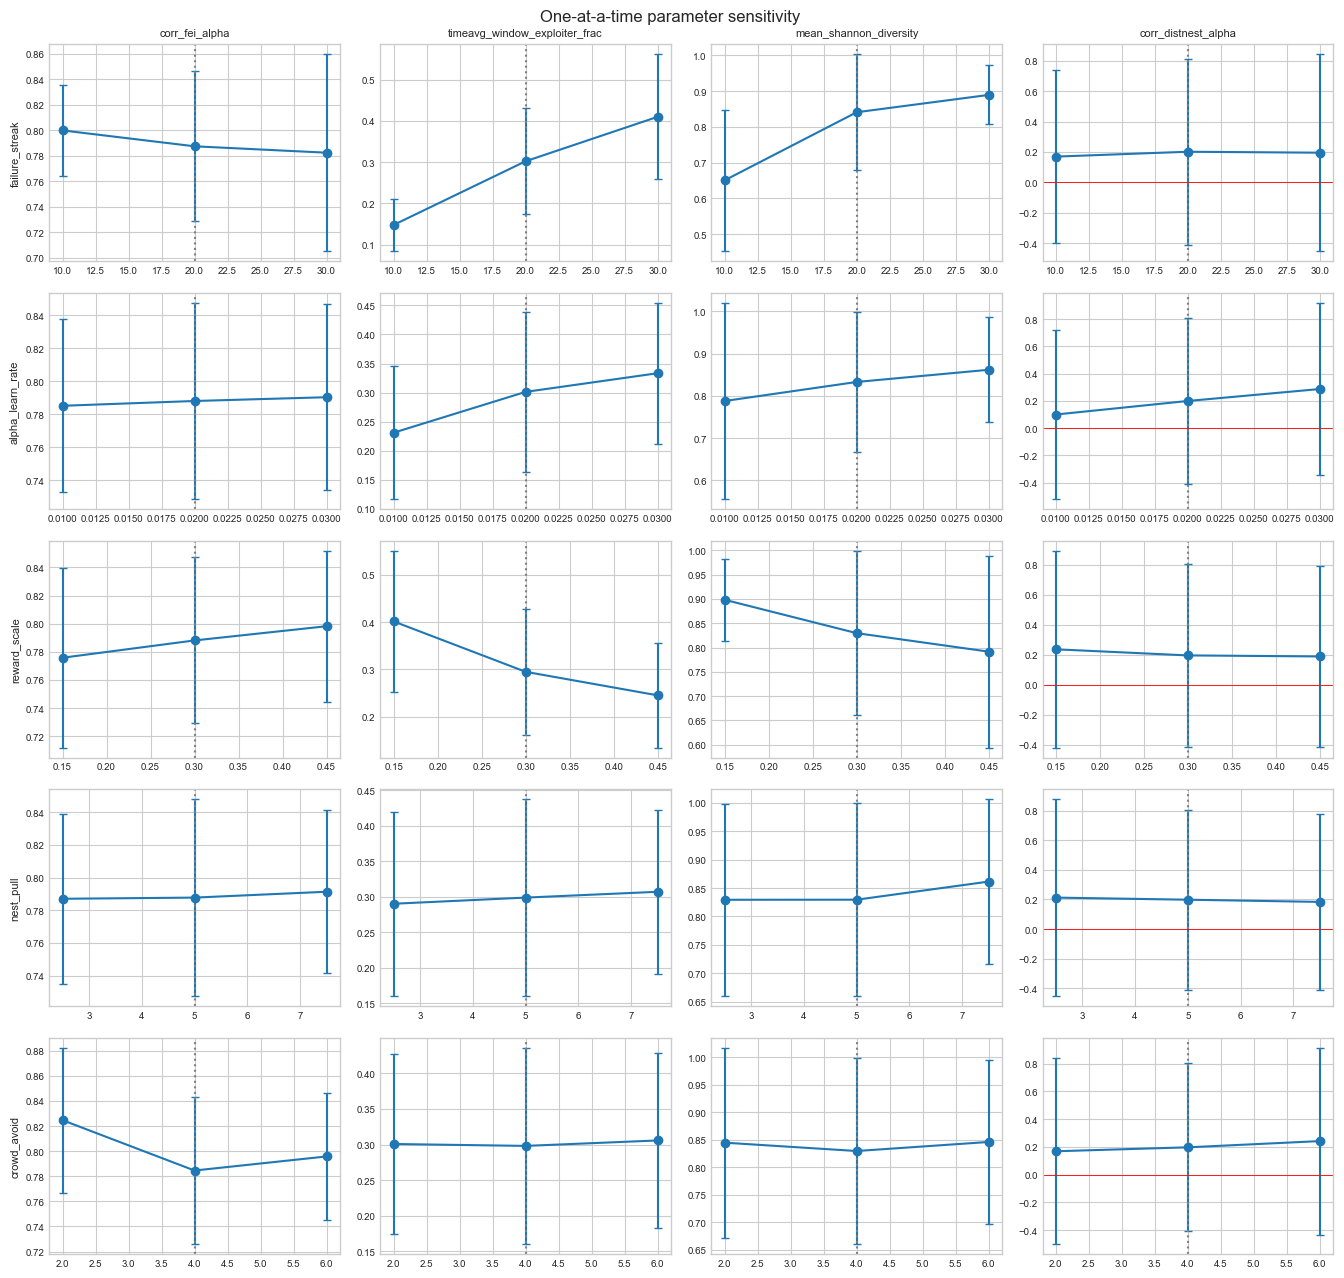

In [21]:
# 10b - Per-constant summary + small-multiples; check corr(FEI, alpha) stays positive.
for _param in OAT_GRID:
    print(f'=== {_param} ===')
    display(oat_sensitivity_summary(oat_df[oat_df[_param].notna()], _param).round(4))
_signs = oat_df['corr_fei_alpha'].dropna()
print('corr(FEI, alpha) across ALL OAT runs: min=%.3f, max=%.3f -> %s'
      % (_signs.min(), _signs.max(),
         'all positive (robust)' if (_signs > 0).all() else 'SOME NON-POSITIVE'))
fig = plot_oat_sensitivity(oat_df, baseline=OAT_BASELINE)
fig.savefig('results/figures/oat_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()